In [1]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
%matplotlib inline

In [2]:
words = open('names.txt','r').read().splitlines()
print(len(words))
words[:7]


32034


['emma', 'olivia', 'ava', 'isabella', 'sophia', 'charlotte', 'mia']

In [3]:
chars = sorted(set(''.join(words)))
stoi = {ch:i+1 for i, ch in enumerate(chars)}
itos = {i+1:ch for i, ch in enumerate(chars)}
stoi['.'] = 0
itos[0] = '.'
sorted(stoi)
sorted(itos)
print(stoi)
print(itos)

{'a': 1, 'b': 2, 'c': 3, 'd': 4, 'e': 5, 'f': 6, 'g': 7, 'h': 8, 'i': 9, 'j': 10, 'k': 11, 'l': 12, 'm': 13, 'n': 14, 'o': 15, 'p': 16, 'q': 17, 'r': 18, 's': 19, 't': 20, 'u': 21, 'v': 22, 'w': 23, 'x': 24, 'y': 25, 'z': 26, '.': 0}
{1: 'a', 2: 'b', 3: 'c', 4: 'd', 5: 'e', 6: 'f', 7: 'g', 8: 'h', 9: 'i', 10: 'j', 11: 'k', 12: 'l', 13: 'm', 14: 'n', 15: 'o', 16: 'p', 17: 'q', 18: 'r', 19: 's', 20: 't', 21: 'u', 22: 'v', 23: 'w', 24: 'x', 25: 'y', 26: 'z', 0: '.'}


In [4]:
block_size = 3
X, Y = [], []
for w in words:
    print(w)
    context = [0]*block_size
    for ch in w+'.':
        ix = stoi[ch]
        X.append(context)
        Y.append(ix)
        # print(''.join(itos[i] for i in context),' ---->', itos[ix])
        context = context[1:] +[ix]

X = torch.tensor(X)
Y = torch.tensor(Y)

    

emma
olivia
ava
isabella
sophia
charlotte
mia
amelia
harper
evelyn
abigail
emily
elizabeth
mila
ella
avery
sofia
camila
aria
scarlett
victoria
madison
luna
grace
chloe
penelope
layla
riley
zoey
nora
lily
eleanor
hannah
lillian
addison
aubrey
ellie
stella
natalie
zoe
leah
hazel
violet
aurora
savannah
audrey
brooklyn
bella
claire
skylar
lucy
paisley
everly
anna
caroline
nova
genesis
emilia
kennedy
samantha
maya
willow
kinsley
naomi
aaliyah
elena
sarah
ariana
allison
gabriella
alice
madelyn
cora
ruby
eva
serenity
autumn
adeline
hailey
gianna
valentina
isla
eliana
quinn
nevaeh
ivy
sadie
piper
lydia
alexa
josephine
emery
julia
delilah
arianna
vivian
kaylee
sophie
brielle
madeline
peyton
rylee
clara
hadley
melanie
mackenzie
reagan
adalynn
liliana
aubree
jade
katherine
isabelle
natalia
raelynn
maria
athena
ximena
arya
leilani
taylor
faith
rose
kylie
alexandra
mary
margaret
lyla
ashley
amaya
eliza
brianna
bailey
andrea
khloe
jasmine
melody
iris
isabel
norah
annabelle
valeria
emerson
adalyn
ryl

In [5]:
X.shape, Y.shape, X.dtype, Y.dtype

(torch.Size([228153, 3]), torch.Size([228153]), torch.int64, torch.int64)

In [6]:
C = torch.randn((27,2))


In [7]:
F.one_hot(torch.tensor(5), num_classes =27).float().shape

torch.Size([27])

In [8]:
C[5]

tensor([-1.3236, -1.6653])

In [9]:
C[torch.tensor([5,6,7])]

tensor([[-1.3236, -1.6653],
        [ 1.2372,  0.2017],
        [-0.0655, -0.1231]])

In [10]:
C[X].shape

torch.Size([228153, 3, 2])

In [11]:
C[Y].shape

torch.Size([228153, 2])

In [12]:
X[0]

tensor([0, 0, 0])

In [13]:
C[X[0]]

tensor([[1.8828, 1.4021],
        [1.8828, 1.4021],
        [1.8828, 1.4021]])

In [14]:
C[X[0][0]]

tensor([1.8828, 1.4021])

In [15]:
C[X][13][2]

tensor([0.7827, 0.2688])

In [16]:
C[X][13,2]

tensor([0.7827, 0.2688])

In [17]:
C

tensor([[ 1.8828,  1.4021],
        [ 0.7827,  0.2688],
        [ 0.2937, -0.2117],
        [-0.4076, -1.5161],
        [ 0.2611, -1.9184],
        [-1.3236, -1.6653],
        [ 1.2372,  0.2017],
        [-0.0655, -0.1231],
        [-0.8787,  0.1795],
        [ 1.8941,  0.7357],
        [-0.9825, -1.5291],
        [ 1.2606,  0.8212],
        [ 1.4400,  1.6503],
        [ 0.6394, -0.1683],
        [ 0.2928,  0.4379],
        [ 1.9322,  0.3001],
        [-1.6456, -1.2222],
        [-0.5693,  0.4460],
        [-1.1010,  0.7092],
        [ 1.2831,  0.8936],
        [ 0.5636,  2.0729],
        [ 1.4146,  0.6311],
        [ 1.2087, -0.7342],
        [ 0.3543,  0.0232],
        [-1.7101, -0.0400],
        [-0.9293, -0.7637],
        [-0.4963, -0.0033]])

In [18]:
C[1,1]

tensor(0.2688)

In [19]:
C[1][1]

tensor(0.2688)

In [20]:
X[13,2]

tensor(1)

In [21]:
emb = C[X]
emb.shape

torch.Size([228153, 3, 2])

In [22]:
W1 = torch.randn((6,100))
b1 = torch.randn(100)

In [23]:
# We wanna do something like
# emb @ W1 +b1 (32,3,2) @ (6,100) + (1, 100)
# Now, We need to concatenate the emb to make it 32, 6 from (32,3,2)

In [24]:
emb.shape

torch.Size([228153, 3, 2])

In [25]:
torch.cat([emb[:, 0, :], emb[:,1, :], emb[:, 2, :]],1).shape

torch.Size([228153, 6])

In [26]:
torch.cat(torch.unbind(emb,1),1)

tensor([[ 1.8828,  1.4021,  1.8828,  1.4021,  1.8828,  1.4021],
        [ 1.8828,  1.4021,  1.8828,  1.4021, -1.3236, -1.6653],
        [ 1.8828,  1.4021, -1.3236, -1.6653,  0.6394, -0.1683],
        ...,
        [-0.4963, -0.0033, -0.4963, -0.0033, -0.9293, -0.7637],
        [-0.4963, -0.0033, -0.9293, -0.7637, -0.4963, -0.0033],
        [-0.9293, -0.7637, -0.4963, -0.0033, -1.7101, -0.0400]])

In [27]:
if any(x==False for x in (emb.view(32,6) == torch.cat(torch.unbind(emb,1),1)).view(-1)):
    print('not equal')
else:
    print('equal')

#So, We can simply use .view()

RuntimeError: shape '[32, 6]' is invalid for input of size 1368918

In [ ]:
h = emb.view(emb.shape[0],6) @ W1 + b1 #Don't hardcode
print(h)
h.shape

tensor([[-1.7969e+00,  5.8114e+00,  4.7971e+00,  ..., -6.0459e-01,
          1.0532e-02,  1.0933e+00],
        [ 1.4526e-01,  5.1348e+00, -5.6619e-01,  ..., -6.7280e+00,
         -2.9917e+00, -2.6924e+00],
        [ 4.8335e+00, -9.0126e-03,  1.0136e+00,  ..., -5.4463e+00,
          1.3722e+00,  6.0567e+00],
        ...,
        [ 2.6018e-01, -2.8533e+00, -3.4249e+00,  ..., -7.9532e+00,
         -3.0508e+00,  1.6071e+00],
        [ 1.0371e+01, -3.1837e+00, -1.2653e+00,  ...,  1.7909e+00,
          5.4274e-01,  7.0952e+00],
        [-1.0699e+00, -3.3379e+00,  8.8584e-02,  ...,  1.3942e-01,
          3.0249e+00,  1.5314e+00]])


torch.Size([32, 100])

In [ ]:
h = torch.tanh(h)
h

tensor([[-0.9465,  1.0000,  0.9999,  ..., -0.5403,  0.0105,  0.7981],
        [ 0.1443,  0.9999, -0.5126,  ..., -1.0000, -0.9950, -0.9909],
        [ 0.9999, -0.0090,  0.7673,  ..., -1.0000,  0.8792,  1.0000],
        ...,
        [ 0.2545, -0.9934, -0.9979,  ..., -1.0000, -0.9955,  0.9227],
        [ 1.0000, -0.9966, -0.8525,  ...,  0.9459,  0.4951,  1.0000],
        [-0.7894, -0.9975,  0.0884,  ...,  0.1385,  0.9953,  0.9107]])

In [ ]:
W2 = torch.randn(100,27)
b2 = torch.randn(27)
logits = h@W2 +b2
# (32,100) @ (100, 27) ->(32,27)
#                                ->(32,27)
#                         (1,27)

In [ ]:
logits.shape
counts = logits.exp()
print(counts[7])
print(counts.shape)
counts= counts/ counts.sum()
counts[7]

tensor([3.0350e-01, 7.7652e-03, 1.2327e+03, 3.5152e-03, 1.4067e+00, 2.3968e-03,
        8.1292e-06, 2.0770e-05, 5.8739e+01, 8.1915e-03, 1.6691e-07, 1.0509e-03,
        2.7228e+00, 3.4250e-03, 9.3923e+06, 2.0138e-06, 1.6549e-02, 1.3392e+00,
        1.0732e+09, 3.7574e-08, 7.4032e+02, 3.8601e+02, 1.8854e+03, 2.0374e+05,
        3.3200e+01, 8.3988e+06, 5.4519e-03])
torch.Size([32, 27])


tensor([4.2850e-14, 1.0963e-15, 1.7404e-10, 4.9630e-16, 1.9860e-13, 3.3839e-16,
        1.1477e-18, 2.9325e-18, 8.2932e-12, 1.1565e-15, 2.3566e-20, 1.4838e-16,
        3.8442e-13, 4.8356e-16, 1.3261e-06, 2.8432e-19, 2.3365e-15, 1.8908e-13,
        1.5152e-04, 5.3050e-21, 1.0452e-10, 5.4499e-11, 2.6619e-10, 2.8765e-08,
        4.6874e-12, 1.1858e-06, 7.6973e-16])

In [ ]:
logits.shape
counts = logits.exp()
print(counts.shape)
# print(counts.sum(1, keepdim=True))
#(32,27)/(32,1)
#(32,7)
#(32,1)
# print(counts.shape)
prob= counts/ counts.sum(1, keepdim=True)
prob.shape

torch.Size([32, 27])


torch.Size([32, 27])

In [ ]:
prob

tensor([[1.7052e-10, 1.2260e-11, 2.8491e-06, 1.7234e-10, 7.4587e-11, 8.3108e-09,
         1.4321e-10, 2.8515e-12, 2.4258e-06, 2.0333e-10, 4.2838e-14, 2.0346e-13,
         2.5073e-11, 2.6569e-12, 4.8160e-06, 3.1481e-13, 4.2712e-11, 6.3708e-11,
         5.2209e-05, 1.2965e-07, 9.6824e-07, 6.5774e-07, 1.4027e-04, 3.2208e-04,
         2.4985e-06, 9.9947e-01, 3.6697e-15],
        [2.5950e-09, 7.6760e-09, 1.1797e-02, 2.0935e-08, 1.8927e-10, 2.3729e-07,
         4.2225e-08, 1.0752e-16, 2.6084e-15, 3.7848e-04, 1.3502e-07, 3.3909e-08,
         7.3783e-05, 2.7995e-10, 9.8774e-01, 2.2552e-10, 1.7519e-12, 2.0319e-11,
         1.2723e-09, 1.3286e-10, 3.6053e-20, 4.5764e-11, 1.1591e-05, 2.4705e-13,
         5.5050e-10, 4.6286e-09, 2.7703e-12],
        [1.9538e-12, 4.9633e-13, 4.1875e-11, 3.1930e-12, 5.7539e-11, 1.9738e-11,
         2.1339e-16, 7.9813e-15, 3.9704e-17, 4.4008e-14, 8.5771e-15, 1.1335e-13,
         9.9942e-01, 5.4949e-14, 5.6611e-13, 3.4850e-07, 1.4789e-13, 1.2551e-09,
         5.8154e-

In [ ]:
prob[torch.arange(32), Y]

tensor([8.3108e-09, 2.7995e-10, 5.4949e-14, 1.0874e-06, 3.7503e-03, 3.1481e-13,
        1.1133e-07, 7.5069e-12, 7.7741e-11, 1.1439e-11, 8.7672e-06, 8.6347e-08,
        1.2260e-11, 4.6751e-05, 3.5284e-16, 2.1851e-06, 2.0333e-10, 2.0106e-11,
        1.0671e-08, 8.9402e-07, 6.4861e-06, 6.2574e-03, 8.1241e-01, 2.1687e-07,
        8.0180e-12, 1.2965e-07, 3.9497e-11, 1.2352e-12, 1.0308e-12, 5.7431e-13,
        4.9755e-08, 3.1446e-11])

In [ ]:
loss = -prob[torch.arange(32), Y].log().mean()
loss

tensor(19.4476)

In [ ]:
prob[torch.arange(32), Y].sum()

tensor(0.8225)

In [ ]:
prob[torch.arange(32), Y]

tensor([8.3108e-09, 2.7995e-10, 5.4949e-14, 1.0874e-06, 3.7503e-03, 3.1481e-13,
        1.1133e-07, 7.5069e-12, 7.7741e-11, 1.1439e-11, 8.7672e-06, 8.6347e-08,
        1.2260e-11, 4.6751e-05, 3.5284e-16, 2.1851e-06, 2.0333e-10, 2.0106e-11,
        1.0671e-08, 8.9402e-07, 6.4861e-06, 6.2574e-03, 8.1241e-01, 2.1687e-07,
        8.0180e-12, 1.2965e-07, 3.9497e-11, 1.2352e-12, 1.0308e-12, 5.7431e-13,
        4.9755e-08, 3.1446e-11])

In [ ]:
X.shape, Y.shape

(torch.Size([228153, 3]), torch.Size([228153]))

In [130]:
g = torch.Generator().manual_seed(2147483647)
C = torch.randn((27,2), generator = g, requires_grad= True)
W1 = torch.randn((6, 100), generator = g, requires_grad= True)
b1 = torch.randn((100), generator = g, requires_grad= True)
W2 = torch.randn((100,27), generator =g, requires_grad= True)
b2 = torch.randn((27), generator = g, requires_grad= True)
parameters = [C, W1, W2, b1, b2] 

In [ ]:
sum(p.nelement() for p in parameters)

3481

In [ ]:

#FORWARD PASS
emb = C[X]
h1 = emb.view(32,6) @ W1 +b1
h1 = torch.tanh(h1)
logits  = h1 @ W2 + b2
#NORMALIZE
counts = logits.exp()
prob = counts/ counts.sum(1, keepdim=True)
#CALCULATE LOSS
loss = -prob[torch.arange(32), Y].log().mean() #loss=1/n(∑​−log(pi​))
loss

In [ ]:
#OR use another way to find the loss(RECDOMMENDED ) COZ MORE EFFICIENT
#FORWARD PASS
for i in range(50):
    emb = C[X]
    h1 = emb.view(-1,6) @ W1 +b1
    h1 = torch.tanh(h1)
    logits  = h1 @ W2 + b2

    #NORMALISE AND CALCULATE LOSS
    loss = F.cross_entropy(logits, Y)

    #Backward pass
    for p in parameters:
        p.grad = None
    loss.backward()

    #update
    for p in parameters:
        p.data += -0.05*p.grad
    print(i+1, loss)

1 tensor(7.4785, grad_fn=<NllLossBackward0>)
2 tensor(7.4026, grad_fn=<NllLossBackward0>)
3 tensor(7.3284, grad_fn=<NllLossBackward0>)
4 tensor(7.2559, grad_fn=<NllLossBackward0>)
5 tensor(7.1851, grad_fn=<NllLossBackward0>)
6 tensor(7.1159, grad_fn=<NllLossBackward0>)
7 tensor(7.0483, grad_fn=<NllLossBackward0>)
8 tensor(6.9823, grad_fn=<NllLossBackward0>)
9 tensor(6.9178, grad_fn=<NllLossBackward0>)
10 tensor(6.8547, grad_fn=<NllLossBackward0>)
11 tensor(6.7932, grad_fn=<NllLossBackward0>)
12 tensor(6.7330, grad_fn=<NllLossBackward0>)
13 tensor(6.6741, grad_fn=<NllLossBackward0>)
14 tensor(6.6165, grad_fn=<NllLossBackward0>)
15 tensor(6.5602, grad_fn=<NllLossBackward0>)
16 tensor(6.5051, grad_fn=<NllLossBackward0>)
17 tensor(6.4511, grad_fn=<NllLossBackward0>)
18 tensor(6.3982, grad_fn=<NllLossBackward0>)
19 tensor(6.3465, grad_fn=<NllLossBackward0>)
20 tensor(6.2957, grad_fn=<NllLossBackward0>)
21 tensor(6.2460, grad_fn=<NllLossBackward0>)
22 tensor(6.1972, grad_fn=<NllLossBackward0

In [ ]:
counts =logits.exp()
prob = counts/ counts.sum(1, keepdim=True)
prob[torch.arange(32), Y]

tensor([0.1961, 0.9132, 0.9800, 0.9757, 0.9641, 0.1892, 0.9191, 0.9566, 0.9528,
        0.9831, 0.9411, 0.9979, 0.2010, 0.8032, 0.9965, 0.9774, 0.1969, 0.9273,
        0.9001, 0.9590, 0.9672, 0.9729, 0.9367, 0.9318, 0.9782, 0.1960, 0.8514,
        0.9672, 0.9767, 0.9538, 0.9837, 0.9743], grad_fn=<IndexBackward0>)

In [ ]:
print(logits.max(1))
print(Y)

torch.return_types.max(
values=tensor([ 7.1606,  7.2297, 12.0873,  ...,  8.3240, 11.7651,  9.4820],
       grad_fn=<MaxBackward0>),
indices=tensor([ 1, 18,  9,  ..., 18, 11, 17]))
tensor([ 5, 13, 13,  ..., 26, 24,  0])


In [28]:
#MINI BATCH
torch.randint(0,5, (32,))

tensor([4, 3, 1, 2, 4, 0, 1, 1, 4, 1, 3, 4, 3, 1, 1, 0, 4, 2, 3, 0, 1, 2, 2, 1,
        4, 2, 1, 4, 4, 0, 0, 3])

In [107]:
for  _ in range(100):
    ix = torch.randint(0, X.shape[0], (32,))
    # print(ix.shape)
    # print(X.shape)
    emb = C[X][ix]
    emb.shape
    # print(emb.shape)
    h1 = torch.tanh(emb.view(-1, 6) @ W1 +b1)
    logits = h1 @W2 +b2
    loss = F.cross_entropy(logits, Y[ix])
    print(loss.item())
    for p in parameters:
        p.grad = None
    loss.backward()
    for p in parameters:
        p.data += -0.1 *p.grad 

print(ix)

51974.8828125
63486.26953125
58050.75390625
61514.5546875
55227.9765625
72280.5703125
60247.9296875
63364.33203125
72705.6328125
60426.68359375
54850.2109375
59802.45703125
59327.06640625
65447.90234375
68616.6171875
61650.15234375
49632.88671875
76631.734375
55851.125
60142.81640625
57061.95703125
62568.7421875
62957.1796875
57698.46875
49519.69921875
68007.375
59309.0
64023.3359375
61462.6953125
58432.5625
64286.6015625
56817.08984375
66561.53125
79572.0546875
56935.9609375
61780.66015625
58475.59375
49391.73046875
49219.5859375
75492.59375
51510.203125
59205.3671875
64559.0234375
64328.44921875
57549.25390625
66872.2734375
59400.39453125
60381.45703125
66085.5078125
46923.6015625
62331.8125
43689.796875
62892.90234375
57054.703125
56735.2265625
60749.1015625
59916.640625
64356.16796875
50443.5546875
69525.859375
62701.2890625
54659.37109375
63536.5625
61821.27734375
59695.6796875
56698.1640625
61105.44921875
47734.5546875
58300.47265625
56403.88671875
57537.05078125
74938.421875
552

In [92]:
emb = C[X]
h1 = torch.tanh(emb.view(-1, 6) @ W1 +b1)
logits = h1 @W2 +b2
loss = F.cross_entropy(logits, Y)
loss.item()


2.8693923950195312

In [7]:
import torch
lre = torch.linspace(-3,0,1000)
lrs = 10**lre
lrs.shape
lre
lrs

tensor([0.0010, 0.0010, 0.0010, 0.0010, 0.0010, 0.0010, 0.0010, 0.0010, 0.0011,
        0.0011, 0.0011, 0.0011, 0.0011, 0.0011, 0.0011, 0.0011, 0.0011, 0.0011,
        0.0011, 0.0011, 0.0011, 0.0012, 0.0012, 0.0012, 0.0012, 0.0012, 0.0012,
        0.0012, 0.0012, 0.0012, 0.0012, 0.0012, 0.0012, 0.0013, 0.0013, 0.0013,
        0.0013, 0.0013, 0.0013, 0.0013, 0.0013, 0.0013, 0.0013, 0.0013, 0.0014,
        0.0014, 0.0014, 0.0014, 0.0014, 0.0014, 0.0014, 0.0014, 0.0014, 0.0014,
        0.0015, 0.0015, 0.0015, 0.0015, 0.0015, 0.0015, 0.0015, 0.0015, 0.0015,
        0.0015, 0.0016, 0.0016, 0.0016, 0.0016, 0.0016, 0.0016, 0.0016, 0.0016,
        0.0016, 0.0017, 0.0017, 0.0017, 0.0017, 0.0017, 0.0017, 0.0017, 0.0017,
        0.0018, 0.0018, 0.0018, 0.0018, 0.0018, 0.0018, 0.0018, 0.0018, 0.0019,
        0.0019, 0.0019, 0.0019, 0.0019, 0.0019, 0.0019, 0.0019, 0.0020, 0.0020,
        0.0020, 0.0020, 0.0020, 0.0020, 0.0020, 0.0021, 0.0021, 0.0021, 0.0021,
        0.0021, 0.0021, 0.0021, 0.0022, 

In [131]:
#understanding GOOD Learning Rate
lri = []
lossi=[]
for  i in range(10000):
    ix = torch.randint(0, X.shape[0], (32,))
    
    emb = C[X][ix]
    emb.shape
    
    h1 = torch.tanh(emb.view(-1, 6) @ W1 +b1)
    logits = h1 @W2 +b2
    loss = F.cross_entropy(logits, Y[ix])
    print(i ,loss.item())
    for p in parameters:
        p.grad = None
    loss.backward()

    # lr = lrs[i]
    lr = 0.1
    for p in parameters:
        p.data += -lr *p.grad #if that int is too high it explodes it vanishes if it is too low
    # lri.append(lre[i])
    # lossi.append(loss.item())
print(loss.item())

# print(ix)

0 20.191089630126953
1 21.100120544433594
2 15.37955093383789
3 15.741446495056152
4 16.684865951538086
5 14.438177108764648
6 14.231650352478027
7 12.391884803771973
8 12.210112571716309
9 12.101362228393555
10 10.564655303955078
11 11.780253410339355
12 9.029126167297363
13 9.671236038208008
14 9.114514350891113
15 7.345164775848389
16 10.181049346923828
17 7.082723140716553
18 6.560729026794434
19 9.253588676452637
20 9.476235389709473
21 10.072420120239258
22 8.308456420898438
23 8.498871803283691
24 7.037848472595215
25 6.623371124267578
26 7.2249064445495605
27 7.077916145324707
28 8.386466026306152
29 8.881462097167969
30 7.0440874099731445
31 8.33137035369873
32 6.095964431762695
33 6.8578410148620605
34 6.53670597076416
35 6.095546722412109
36 7.493756294250488
37 6.002876281738281
38 6.937425136566162
39 5.92811918258667
40 6.253574371337891
41 5.317224979400635
42 6.934496879577637
43 5.061562538146973
44 7.4346699714660645
45 5.117001056671143
46 6.925990104675293
47 6.9476

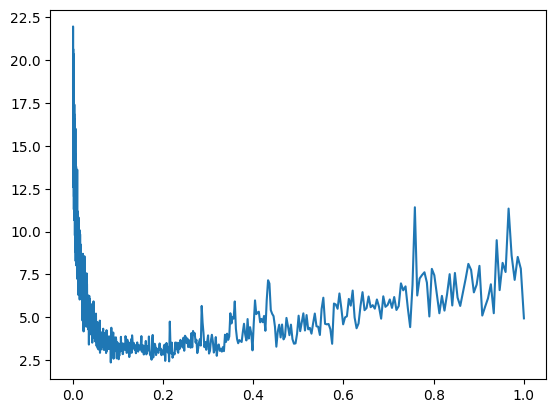

In [ ]:
plt.plot( lri, lossi)
# We can see 0.1 is optimal lr

In [188]:
#TRAIN-TEST-VALID SET
import numpy as np
def build_dataset(words):
    block_size = 6
    X,Y = [],[]
    for w in words:
        ch = w+'.'
        context = [0] * block_size
        for c in ch: 
            ix = stoi[c]
            X.append(context)
            
            Y.append(ix)
            context = context[1:] + [ix]
    print(np.array(X).shape)
    print(np.array(Y).shape)
    # print(X)
    X = torch.tensor(X)
    Y = torch.tensor(Y)
    return X, Y
    
import random 
random.seed(42)
random.shuffle(words)
n1 = int(0.8*len(words))
n2 = int(0.9* len(words))

Xtr, Ytr = build_dataset(words[:n1])
Xval, Yval = build_dataset(words[n1:n2])
Xtst, Ytst = build_dataset(words[n2:])


(182538, 6)
(182538,)
(22941, 6)
(22941,)
(22674, 6)
(22674,)


In [189]:
Xtr.shape, Ytr.shape, Xval.shape, Yval.shape, Xtst.shape, Ytst.shape

(torch.Size([182538, 6]),
 torch.Size([182538]),
 torch.Size([22941, 6]),
 torch.Size([22941]),
 torch.Size([22674, 6]),
 torch.Size([22674]))

In [ ]:
g = torch.Generator().manual_seed(2147483647)
C = torch.randn((27,2), generator = g, requires_grad= True)
W1 = torch.randn((6, 100), generator = g, requires_grad= True)
b1 = torch.randn((100), generator = g, requires_grad= True)
W2 = torch.randn((100,27), generator =g, requires_grad= True)
b2 = torch.randn((27), generator = g, requires_grad= True)
parameters = [C, W1, W2, b1, b2] 

In [156]:
#TRAIN
#understanding GOOD Learning Rate
lri = []
lossi=[]
for  i in range(1000):
    ix = torch.randint(0, Xtr.shape[0], (32,))
    
    emb = C[Xtr][ix]
    emb.shape
    
    h1 = torch.tanh(emb.view(-1, 6) @ W1 +b1)
    logits = h1 @W2 +b2
    loss = F.cross_entropy(logits, Ytr[ix])
    print(i ,loss.item())
    for p in parameters:
        p.grad = None
    loss.backward()

    # lr = lrs[i]
    lr = 0.1
    for p in parameters:
        p.data += -lr *p.grad #if that int is too high it explodes it vanishes if it is too low
    # lri.append(lre[i])
    # lossi.append(loss.item())
print(loss.item())

# print(ix)

0 20.099225997924805
1 15.944840431213379
2 18.808645248413086
3 14.12100887298584
4 14.514191627502441
5 15.538408279418945
6 13.53781795501709
7 11.508894920349121
8 12.038769721984863
9 12.39769458770752
10 11.392894744873047
11 10.237557411193848
12 9.710206985473633
13 9.406353950500488
14 7.727105617523193
15 9.125593185424805
16 11.681523323059082
17 6.430058002471924
18 8.872486114501953
19 8.990649223327637
20 8.962581634521484
21 9.534712791442871
22 9.375406265258789
23 8.525681495666504
24 6.611088275909424
25 7.375385761260986
26 7.467026233673096
27 6.791003704071045
28 9.34266471862793
29 7.900819301605225
30 6.675529956817627
31 5.465838432312012
32 7.4707489013671875
33 6.2324628829956055
34 8.299982070922852
35 7.858384609222412
36 7.170653343200684
37 4.594292163848877
38 6.915403842926025
39 7.023763179779053
40 5.873298645019531
41 5.200958251953125
42 3.810910224914551
43 6.600695610046387
44 6.8304901123046875
45 5.497056007385254
46 4.429121017456055
47 7.186735

In [ ]:
#Val Loss
emb  = C[Xval]
h1 = torch.tanh(emb.view(-1, 6) @ W1 +b1)
logits = h1 @W2 +b2
loss = F.cross_entropy(logits, Yval)
loss

tensor(2.6635, grad_fn=<NllLossBackward0>)

In [ ]:
#Train LOSS
emb  = C[Xtr]
h1 = torch.tanh(emb.view(-1, 6) @ W1 +b1)
logits = h1 @W2 +b2
loss = F.cross_entropy(logits, Ytr)
loss

tensor(2.6589, grad_fn=<NllLossBackward0>)

In [196]:
#WE CAN SEE almost{loss(val) == loss(train)]
#  which means our model is underfitting.
# we can solve this by making our neural net more desnse.
g = torch.Generator().manual_seed(2147483647)
C = torch.randn((27,10), generator = g, requires_grad= True)
W1 = torch.randn((60, 400), generator = g, requires_grad= True)
b1 = torch.randn((400), generator = g, requires_grad= True)
W2 = torch.randn((400,27), generator =g, requires_grad= True)
b2 = torch.randn((27), generator = g, requires_grad= True)
parameters = [C, W1, W2, b1, b2] 

In [197]:
sum(p.nelement() for p in parameters)

35497

In [198]:
lre = torch.linspace(-3, 0, 150000)
lrs = 10**lre

In [199]:
lri = []
lossi=[]
stepi = []

In [200]:
#TRAIN
#understanding GOOD Learning Rate
for  i in range(15000):
    ix = torch.randint(0, Xtr.shape[0], (32,))
    
    emb = C[Xtr][ix]
    emb.shape
    
    h1 = torch.tanh(emb.view(-1, 60) @ W1 +b1)
    logits = h1 @W2 +b2
    loss = F.cross_entropy(logits, Ytr[ix])
    print(i ,loss.item())
    for p in parameters:
        p.grad = None
    loss.backward()

    # lr = lrs[i]
    lr = 0.1 if i< 7500 else 0.01
    for p in parameters:
        p.data += -lr *p.grad #if that int is too high it explodes it vanishes if it is too low
    # lri.append(lre[i])
    stepi.append(i)
    lossi.append(loss.item())
print(loss.item())

# print(ix)

0 34.96417236328125
1 23.9470272064209
2 25.968061447143555
3 26.93583106994629
4 27.262197494506836
5 29.71612548828125
6 21.998477935791016
7 22.20817756652832
8 30.489234924316406
9 25.919002532958984
10 25.96514892578125
11 22.18831443786621
12 22.881608963012695
13 19.72198486328125
14 24.662452697753906
15 24.129268646240234
16 20.521949768066406
17 22.790443420410156
18 17.658504486083984
19 25.620525360107422
20 16.670930862426758
21 17.9215087890625
22 17.303028106689453
23 24.595706939697266
24 20.87871551513672
25 15.0038423538208
26 16.94609832763672
27 18.549285888671875
28 11.279974937438965
29 16.556257247924805
30 19.719751358032227
31 17.500492095947266
32 14.886337280273438
33 21.54511260986328
34 22.894935607910156
35 13.925957679748535
36 18.414522171020508
37 15.921677589416504
38 14.89185905456543
39 18.66583824157715
40 13.378527641296387
41 11.29024887084961
42 16.352611541748047
43 17.904197692871094
44 17.733108520507812
45 14.150025367736816
46 17.88144874572

In [201]:
#Train LOSS
emb  = C[Xtr]
h1 = torch.tanh(emb.view(-1, 60) @ W1 +b1)
logits = h1 @W2 +b2
loss = F.cross_entropy(logits, Ytr)
loss

tensor(2.5316, grad_fn=<NllLossBackward0>)

In [202]:
#Val Loss
emb  = C[Xval]
h1 = torch.tanh(emb.view(-1, 60) @ W1 +b1)
logits = h1 @W2 +b2
loss = F.cross_entropy(logits, Yval)
loss

tensor(2.5444, grad_fn=<NllLossBackward0>)

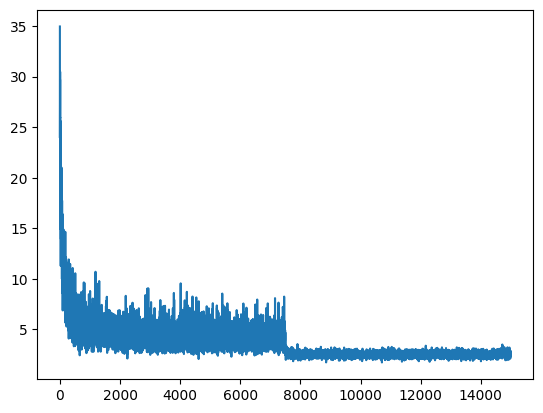

In [204]:
plt.plot(stepi,lossi)

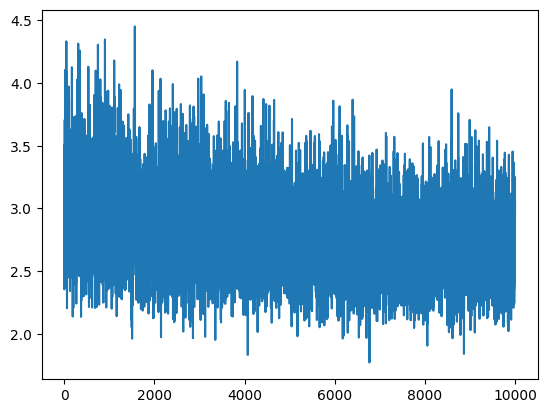

In [187]:
plt.plot(stepi,lossi)

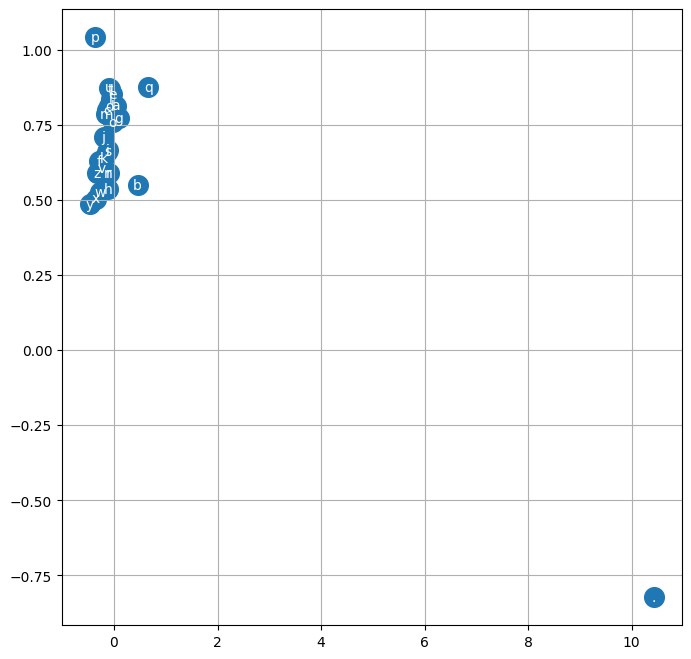

In [205]:
plt.figure(figsize=(8,8))
plt.scatter(C[:,0].data, C[:,1].data, s=200)
for i in range(C.shape[0]):
    plt.text(C[i,0].item(), C[i,1].item(),itos[i], ha='center', va = 'center', color='w')
plt.grid()

In [211]:
g = torch.Generator().manual_seed(21474836 +10)
for i in range(20):
    out = []
    context = [0] *6
    while True:
        emb = C[torch.tensor([context])]
        h = torch.tanh(emb.view(1, -1) @ W1 +b1)
        logits = h@ W2 +b2 
        probs = F.softmax(logits, dim = 1)
        ix = torch.multinomial(probs, num_samples=1, generator = g).item()
        context = context[1:] +[ix]
        out.append(ix)
        if ix == 0:
            break

    print(''.join(itos[i] for i in out))

ndiwne.
ouieyl.
ceyiaro.
ailhnse.
jmaoei.
lizty.
nlnzrni.
zlsaia.
yeoiin.
aleyaallsah.
vllis.
eimgay.
cmran.
bhnrtra.
mlsrnil.
kiycer.
caayyi.
dnfoyl.
sosni.
annpni.


In [213]:
torch.save({"C": C, "W1": W1, "b1": b1, "W2": W2, "b2": b2, "stoi": stoi, "itos": itos}, "makemore_checkpoint.pt")
ckpt = torch.load("makemore_checkpoint.pt")
C, W1, b1, W2, b2 = ckpt["C"], ckpt["W1"], ckpt["b1"], ckpt["W2"], ckpt["b2"]
stoi, itos = ckpt["stoi"], ckpt["itos"]